# 07 Coastal Flood Risk (Delft-FIAT)

> **Stage Contract**
>
> Requires: the FIAT model (built here once from NSI + HAZUS), `catalog_risk_metadata.json` from `03`, and completed SFINCS `run_outputs` (from `05` + cluster).
>
> Produces: per-asset damage, Expected Annual Damage (EAD) per SLR scenario, audit receipts, and risk artifacts under `data/fiat/risk`.
>
> Method: Delft-FIAT is the per-event **damage engine**; the probability integration into EAD is done here with the catalog's importance-sampling weights, because the events are *compound* (no single return period). A FIAT-native return-period risk run is included only as a coarse cross-check.

**Environment:** hydromt_fiat / delft_fiat cannot share the main hydromt-1.x SFINCS env, so they live in an isolated conda env (`fiat`). This notebook runs in the main kernel and shells into that env via `fiat_runs` for the build/engine steps; hazard export and EAD integration run here.

In [ ]:
import sys, json, time
from pathlib import Path

notebook_root = Path.cwd().resolve()
location_root = notebook_root.parent
repo_root = location_root.parents[1]
src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))
config_yaml = location_root / "config.yaml"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from fiat_runs import (
    load_runtime, fiat_paths, fiat_env_available,
    build_fiat_model, apply_dem_ground_elevation, fiat_model_is_built,
    WaterLevelRasterizer, run_fiat_event, diagnostics, risk, risk_native, validate,
)

config, paths = load_runtime(config_yaml)
paths = fiat_paths(paths)
pd.set_option("display.max_columns", 80)

# Completed events to process interactively. EAD is only complete over the full synthetic
# catalog (500 events); set EVENT_LIMIT = None for the headline numbers.
EVENT_LIMIT = 25
catalog_csv = paths["design_outputs_root"] / "catalog" / "event_catalog.csv"
metadata_json = paths["design_outputs_root"] / "catalog" / "catalog_risk_metadata.json"
model_root = paths["fiat_model_root"]

## Step 0 - Stage input audit

Confirm the isolated FIAT env, the event catalog + risk metadata from `03`, and which SFINCS runs are completed (keyed on their SLR scenario). Hard-fail early with an actionable message.

In [ ]:
inputs = {
    "fiat_env_available": fiat_env_available(),
    "fiat_model_built": fiat_model_is_built(paths),
    "event_catalog": catalog_csv.exists(),
    "catalog_risk_metadata": metadata_json.exists(),
    "storage_root": str(paths["storage_root"]),
}
display(pd.Series(inputs, name="stage_inputs"))

if not inputs["fiat_env_available"]:
    raise RuntimeError(
        "conda 'fiat' env is missing hydromt_fiat/delft_fiat. Create it: "
        "mamba create -n fiat -c conda-forge python=3.12 gdal delft_fiat && "
        "conda run -n fiat pip install hydromt_fiat"
    )
if not (inputs["event_catalog"] and inputs["catalog_risk_metadata"]):
    raise FileNotFoundError(
        "Missing event_catalog.csv or catalog_risk_metadata.json. Run 03_build_event_catalog "
        "(including the catalog_risk_metadata export cell) first."
    )


def completed_runs(storage_root):
    rows = []
    for d in sorted(Path(storage_root).glob("*")):
        mp = d / "sfincs_map.nc"
        if not mp.exists():
            continue
        scenario = "base"
        manifest = d / "forcing_manifest.json"
        if manifest.exists():
            try:
                scenario = json.loads(manifest.read_text()).get("design_scenario", "base")
            except Exception:
                pass
        rows.append({"event_id": d.name, "design_scenario": scenario, "map_path": str(mp)})
    return pd.DataFrame(rows)


runs = completed_runs(paths["storage_root"])
if runs.empty:
    raise RuntimeError("No completed SFINCS run_outputs found. Run 05 + the cluster job first.")
display(runs.groupby("design_scenario").size().rename("completed_sfincs_runs"))

fiat_env_available                                                    True
fiat_model_built                                                      True
event_catalog                                                         True
catalog_risk_metadata                                                 True
storage_root             /home/grahamhults/projects/Flood-RM/locations/...
Name: stage_inputs, dtype: object

design_scenario
base    500
Name: completed_sfincs_runs, dtype: int64

## Step 1 - Build the FIAT model (once)

Exposure is the USACE **National Structure Inventory** (NSI); vulnerability is the FEMA/**HAZUS** depth-damage curves; both come from the hydromt_fiat bundled USA catalog (recipe: `fiat_config.yml`). Ground elevation is then re-sampled from the high-resolution **SFINCS subgrid DEM** so the FIAT ground and the SFINCS water level share one vertical datum (offline coupling) - this is what keeps per-structure depths, and damage magnitudes, credible.

In [ ]:
if not fiat_model_is_built(paths):
    receipt = build_fiat_model(config, paths)   # one-time NSI pull + HAZUS linking (isolated env)
else:
    receipt = {"reused": True, "model_root": str(model_root)}

# Idempotent: ensure exposure ground elevation comes from the SFINCS DEM (not NSI NAVD88).
ground = apply_dem_ground_elevation(config, paths)

display(pd.Series({
    "model_root": str(model_root),
    "n_exposure_assets": receipt.get("n_exposure_assets"),
    "structures_grounded": ground["structures_grounded"],
    "ground_ft_median": round(ground["ground_ft_median"], 2),
    "exposure": "NSI", "vulnerability": "HAZUS IWR curves",
}, name="fiat_model"))

model_root             /home/grahamhults/projects/Flood-RM/locations/...
n_exposure_assets                                                   None
structures_grounded                                                13223
ground_ft_median                                                   40.24
exposure                                                             NSI
vulnerability                                           HAZUS IWR curves
Name: fiat_model, dtype: object

## Step 2 - Export per-event hazard + run Delft-FIAT

For each completed event we rasterise the SFINCS peak **water level** (`zsmax`, feet) onto a regular grid, masked to cells with both event depth (`zsmax - zb`) and storm increment (`zsmax - zs_t0`) above `huthresh`, then run FIAT single-event (`risk=false`). FIAT subtracts each structure's DEM ground elevation and NSI ground-floor height to get inundation depth, applies the HAZUS curve, and returns per-asset structure + content damage.

This notebook **does** provide an event-level FIAT damage screen and a weighted-event EAD calculation over whichever synthetic events are processed. It **does not** calibrate NSI exposure values, validate HAZUS curves against Marshfield claims data, create a FEMA-style flood map, or make a headline EAD when `EVENT_LIMIT` is set. The diagnostic tables below are the review gate for whether big numbers come from hazard, exposure value, vulnerability-curve behavior, or a few high-value assets.

Hazard note: water level is on the 60 m SFINCS grid; the per-structure ground is at 10 m. The wet/incremental mask prevents dry-cell terrain noise and permanent/tidal water from being handed to FIAT as event flooding. The maps below plot **depth** for readability and hide open-water bathymetry so offshore propagation does not dominate landward impact review.

In [ ]:
weights = risk.load_catalog_weights(catalog_csv)
total_rate = risk.total_rate_from_metadata(metadata_json)

selected = runs if EVENT_LIMIT is None else runs.groupby("design_scenario", group_keys=False).head(EVENT_LIMIT)
rasterizer = WaterLevelRasterizer(selected.iloc[0]["map_path"])  # grid geometry shared by all runs

damage_rows = []
t0 = time.time()
for r in selected.itertuples(index=False):
    haz = paths["fiat_hazard_root"] / r.design_scenario / f"{r.event_id}.tif"
    rasterizer.export(r.map_path, haz)
    out_dir = paths["fiat_risk_root"] / r.design_scenario / r.event_id
    res = run_fiat_event(model_root, haz, out_dir, event_id=r.event_id)
    res["design_scenario"] = r.design_scenario
    damage_rows.append(res)

per_event_damage = pd.DataFrame(damage_rows)
print(f"ran {len(per_event_damage)} FIAT events in {time.time() - t0:.0f}s")
display(per_event_damage.sort_values("total_damage", ascending=False)[
    ["event_id", "design_scenario", "total_damage", "n_assets_damaged"]
].head(12))

exposure_csv = model_root / "exposure" / "exposure.csv"
vulnerability_csv = model_root / "vulnerability" / "vulnerability_curves.csv"
review = per_event_damage.sort_values("total_damage", ascending=False).iloc[0]
review_run = selected[(selected["event_id"] == review.event_id) & (selected["design_scenario"] == review.design_scenario)].iloc[0]
review_damage = diagnostics.load_event_damage(
    paths["fiat_risk_root"], review.event_id, scenario=review.design_scenario, exposure_csv=exposure_csv
)

audit_rows = []
for r in per_event_damage.sort_values("total_damage", ascending=False).head(12).itertuples(index=False):
    event_damage = diagnostics.load_event_damage(
        paths["fiat_risk_root"], r.event_id, scenario=r.design_scenario, exposure_csv=exposure_csv
    )
    audit_rows.append({"event_id": r.event_id, "design_scenario": r.design_scenario, **diagnostics.event_damage_summary(event_damage)})

damage_audit = pd.DataFrame(audit_rows)
display(damage_audit[[
    "event_id", "design_scenario", "total_damage", "n_assets_damaged",
    "top10_damage_share_pct", "median_inun_depth_ft", "p95_inun_depth_ft",
    "low_depth_damage", "low_depth_damage_pct", "median_loss_ratio", "p95_loss_ratio",
]])
display(diagnostics.damage_by_depth_band(review_damage))
display(diagnostics.damage_by_occupancy(review_damage).head(8))
display(diagnostics.top_damaged_assets(review_damage, n=12))
display(diagnostics.nonzero_negative_depth_curves(vulnerability_csv).head(12))

fig, ax = plt.subplots(figsize=(8, 7))
ax, mesh = diagnostics.plot_flood_depth(
    review_run.map_path,
    ax=ax,
    basemap_style="dark",
    land_min_elev_m=-0.5,
    title=f"{review.event_id}: land-focused masked SFINCS flood depth",
)
cbar = fig.colorbar(mesh, ax=ax, shrink=0.9)
cbar.set_label("Flood Depth (feet)")
plt.tight_layout()

fig, ax = plt.subplots(figsize=(8, 7))
diagnostics.plot_damaged_assets(
    review_damage,
    ax=ax,
    basemap_style="dark",
    title=f"{review.event_id}: damaged FIAT assets",
)
plt.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
depth_bands = diagnostics.damage_by_depth_band(review_damage)
axes[0].bar(depth_bands["depth_band_ft"].astype(str), depth_bands["damage"] / 1e6, color="#2b8cbe")
axes[0].set_ylabel("Damage ($M)")
axes[0].set_title("Damage by FIAT inundation depth")
axes[0].tick_params(axis="x", rotation=45)
occupancy = diagnostics.damage_by_occupancy(review_damage).head(6)
axes[1].bar(occupancy["primary_object_type"].astype(str), occupancy["damage"] / 1e6, color="#f03b20")
axes[1].set_ylabel("Damage ($M)")
axes[1].set_title("Damage by NSI occupancy")
plt.tight_layout()

## Step 3 - Weighted-event Expected Annual Damage

`EAD = total_rate_per_year * sum_i (probability_weight_i * loss_i)` over the synthetic events
(`historical_tail` excluded). The audit receipt shows the weight closure (must be ~1.0 over the
full catalog), the rate used, and the `weight_coverage` actually present.

> **Caveat:** with `EVENT_LIMIT` set, `weight_coverage < 1` and the EAD is **partial**. For the
> headline EAD set `EVENT_LIMIT = None` so all synthetic events are included.

total_rate_per_year                                          8.93
synthetic_weight_sum                                          1.0
synthetic_event_count                                         500
expected_event_count                                          500
events_with_damage_and_weight                                  25
ead_origins                      [synthetic_body, synthetic_tail]
Name: ead_audit, dtype: object

,design_scenario,n_events,weight_coverage,total_rate_per_year,expected_event_damage,ead,ead_delta_vs_base
0,base,25,0.742982,8.93,4.083562e+06,3.646621e+07,0.0


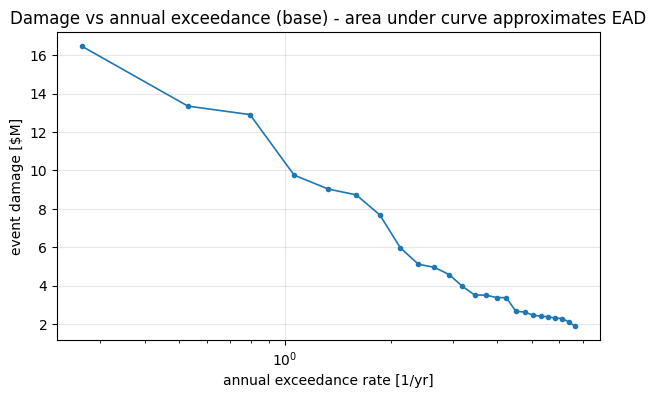

In [ ]:
audit = risk.ead_audit(per_event_damage, weights, total_rate, expected_event_count=len(weights))
display(pd.Series({k: v for k, v in audit.items() if k != "ead_by_scenario"}, name="ead_audit"))

ead_table = risk.ead_by_scenario(per_event_damage, weights, total_rate)
display(ead_table)

base_damage = per_event_damage[per_event_damage["design_scenario"] == "base"]
exceedance = risk.damage_exceedance_curve(base_damage, weights, total_rate)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(exceedance["exceedance_rate_per_year"], exceedance["total_damage"] / 1e6, marker=".", lw=1.2)
ax.set_xscale("log")
ax.set_xlabel("annual exceedance rate [1/yr]")
ax.set_ylabel("event damage [$M]")
ax.set_title("Damage vs annual exceedance (base) - area under curve approximates EAD")
ax.grid(True, alpha=0.3)
plt.show()

## Step 4 - FIAT-native return-period risk (cross-check)

Independent sanity bound: pick the synthetic event nearest each target return period (10/50/100/500 yr by joint RP), stack their water-level maps as RP bands, and let Delft-FIAT integrate EAD log-linearly over the exceedance probabilities. This is **approximate** (joint RP != marginal RP; one event per RP) and is expected to differ from the weighted-event EAD - it is a bound, not ground truth.

In [ ]:
rp_events = risk_native.select_rp_representatives(catalog_csv)
try:
    native = risk_native.run_native_rp_risk(
        model_root, rasterizer, paths["storage_root"], rp_events,
        paths["fiat_risk_root"] / "_native_rp", paths["fiat_hazard_root"] / "_native_rp",
    )
    display(pd.Series(native, name="native_rp_risk"))
    base_ead = ead_table.loc[ead_table["design_scenario"] == "base", "ead"]
    if len(base_ead):
        display(pd.Series({
            "weighted_event_ead_base": float(base_ead.iloc[0]),
            "native_rp_ead": native["ead"],
            "ratio_native_over_weighted": native["ead"] / float(base_ead.iloc[0]) if base_ead.iloc[0] else None,
        }, name="ead_crosscheck"))
except Exception as exc:
    native = {"error": str(exc)}
    print("native RP cross-check skipped:", exc)

method                                          fiat_native_rp_risk
return_periods                                   [10, 50, 100, 500]
rp_events         {10: 'design_0173', 50: 'design_0309', 100: 'd...
ead                                                       644256.92
ead_column                                               ead_damage
Name: native_rp_risk, dtype: object

weighted_event_ead_base       3.646621e+07
native_rp_ead                 6.442569e+05
ratio_native_over_weighted    1.766723e-02
Name: ead_crosscheck, dtype: float64

## Step 5 - Historical-event validation

Run FIAT on the real `historical_tail` storms (e.g. the 1991 and 1992 nor'easters) as a
non-parametric check - their modeled damage should sit plausibly within the synthetic
distribution. Not used in the EAD. Requires the historical events to have completed SFINCS
runs (stage + run them like the SLR scenarios); missing runs are reported, not fatal.

In [ ]:
hist = validate.run_historical_validation(
    model_root, rasterizer, paths["storage_root"], catalog_csv,
    paths["fiat_risk_root"] / "historical", paths["fiat_hazard_root"] / "historical",
)
display(pd.Series({k: v for k, v in hist.items() if k != "damages"}, name="historical_validation"))
if hist["n_run"]:
    display(hist["damages"][["event_id", "total_damage", "n_assets_damaged", "coastal_absolute_peak_m"]])
else:
    print("No historical SFINCS runs yet - stage and run the historical_tail events through 05 + cluster.")

n_historical                                                          10
n_run                                                                  0
missing_sfincs_runs    [historical_20100224T060000, historical_202110...
Name: historical_validation, dtype: object

No historical SFINCS runs yet - stage and run the historical_tail events through 05 + cluster.


## Step 6 - Write risk outputs

In [ ]:
risk_root = paths["fiat_risk_root"]
risk_root.mkdir(parents=True, exist_ok=True)

per_event_damage.to_csv(risk_root / "per_event_damage.csv", index=False)
ead_table.to_csv(risk_root / "ead_by_scenario.csv", index=False)
exceedance.to_csv(risk_root / "damage_exceedance_base.csv", index=False)
(risk_root / "ead_audit.json").write_text(json.dumps(audit, indent=2, default=str), encoding="utf-8")
(risk_root / "ead_crosscheck.json").write_text(json.dumps(native, indent=2, default=str), encoding="utf-8")
if hist["n_run"]:
    hist["damages"].to_csv(risk_root / "historical_validation.csv", index=False)

summary = {
    "event_count": int(len(per_event_damage)),
    "event_limit": EVENT_LIMIT,
    "scenarios": sorted(per_event_damage["design_scenario"].unique().tolist()),
    "total_rate_per_year": total_rate,
    "synthetic_weight_sum": audit["synthetic_weight_sum"],
    "weighted_ead_by_scenario": ead_table.to_dict("records"),
    "native_rp_ead": native.get("ead"),
    "historical_runs": hist["n_run"],
}
(risk_root / "summary.json").write_text(json.dumps(summary, indent=2, default=str), encoding="utf-8")
display(pd.Series({
    "per_event_damage": str(risk_root / "per_event_damage.csv"),
    "ead_by_scenario": str(risk_root / "ead_by_scenario.csv"),
    "summary": str(risk_root / "summary.json"),
}, name="risk_outputs"))

per_event_damage    /home/grahamhults/projects/Flood-RM/locations/...
ead_by_scenario     /home/grahamhults/projects/Flood-RM/locations/...
summary             /home/grahamhults/projects/Flood-RM/locations/...
Name: risk_outputs, dtype: str